In [1]:
library(Seurat)
library(data.table)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
options(repr.plot.width = 12, repr.plot.height = 6)

In [3]:
print_seurat_stats <- function(seurat_object) {
  remaining_cells <- ncol(seurat_object)
  remaining_genes <- nrow(seurat_object)
  cat("Number of cells:", remaining_cells, "\n")
  cat("Number of genes:", remaining_genes, "\n")
}

In [4]:
data_dir <- "PREPROCESING/INPUT/173ctrl/sample_filtered_feature_bc_matrix"
data <- Read10X(data.dir = data_dir)

In [5]:
seurat_object <- CreateSeuratObject(counts = data)

In [6]:
print_seurat_stats(seurat_object)

Number of cells: 514 
Number of genes: 38606 


In [7]:
cells <- fread("PREPROCESING/INPUT/173ctrl/sample_filtered_barcodes.csv", select = "Barcode")
seurat_object_use <- subset(seurat_object, cells = cells$Barcode)

Warning message in fread("PREPROCESING/INPUT/173ctrl/sample_filtered_barcodes.csv", :
“Column name 'Barcode' not found in column name header (case sensitive), skipping.”


In [8]:
print_seurat_stats(seurat_object_use)

Number of cells: 514 
Number of genes: 38606 


In [9]:
seurat_object_use[["percent.mt"]] <- PercentageFeatureSet(seurat_object_use, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


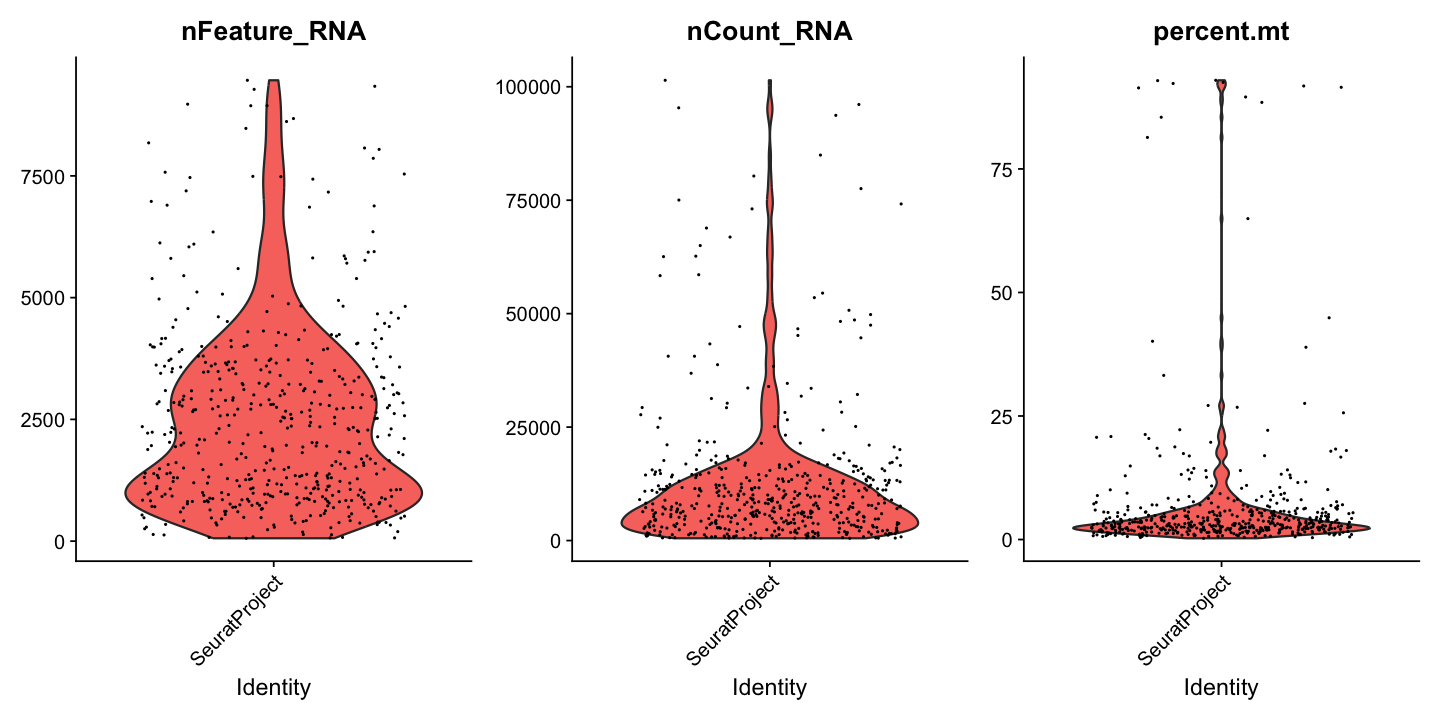

In [10]:
VlnPlot(seurat_object_use, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

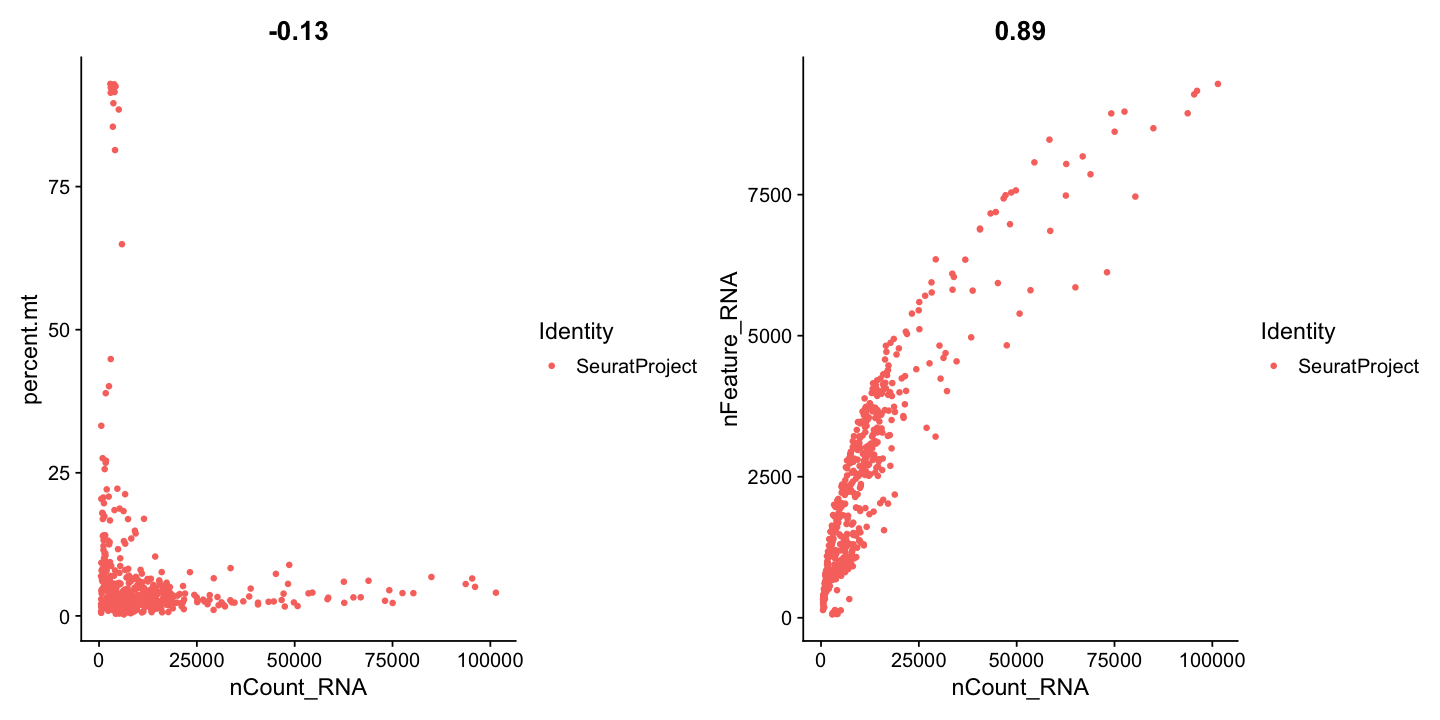

In [11]:
plot1 <- FeatureScatter(seurat_object_use, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(seurat_object_use, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [12]:
seurat_object_filt <- subset(
  seurat_object_use,
  subset = nFeature_RNA > 500 & nCount_RNA > 500 & percent.mt < 20
)

In [13]:
print_seurat_stats(seurat_object_filt)

Number of cells: 460 
Number of genes: 38606 


In [14]:
seurat_object_filt <- NormalizeData(seurat_object_filt)
seurat_object_filt <- FindVariableFeatures(seurat_object_filt, selection.method = "vst", nfeatures = 2000)

Normalizing layer: counts

Finding variable features for layer counts



In [15]:
all.genes <- rownames(seurat_object_filt)
seurat_object_filt <- ScaleData(seurat_object_filt, features = all.genes)

Centering and scaling data matrix



In [15]:
saveRDS(seurat_object_filt, file = "PREPROCESING/SAMPLE_OUT/173ctrl.rds")